# Differentiable Ultrasound from MRI: Impedance Mapping from MRI

This notebook demonstrates a workflow for computing the impedance map from the MRI

The pipeline includes:
- Data preparation and visualization of tissue characteristics
- Training a multi-layer perceptron (MLP) to learn the mapping from MRI intensities to acoustic impedance

The code is modular and leverages PyTorch, NumPy, Matplotlib, and domain-specific utilities for medical imaging and simulation. The trained model is then stored in `./MLP/`.

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import os

import sys
import pathlib

PROJECT_ROOT = pathlib.Path().cwd().parent
sys.path.append(str(PROJECT_ROOT))
data_path = PROJECT_ROOT / 'data'

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

# =====================
# Plot Settings
# =====================
plt.style.use('seaborn-v0_8-paper')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Palatino', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'axes.linewidth': 1.2,
    'grid.color': '0.8',
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'figure.figsize': (7, 5),
    'figure.autolayout': True,
    'mathtext.fontset': 'stix'
})

Below, we define our MLP architecture:

In [3]:
class ImpedanceEstimator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        self.min_MRI = 0.0
        self.max_MRI = 1.0
    def forward(self, x):
        # Normalize input
        x = self.max_MRI * (x - torch.min(x)) / (torch.max(x) - torch.min(x)) + self.min_MRI
        return self.net(x)
    
    @staticmethod
    def train_model(X, y, input_dim=1, epochs=1000, lr=0.01):
        # add a scaler
        model = ImpedanceEstimator(input_dim)
        model.min_MRI = X.min().item()
        model.max_MRI = X.max().item()
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        all_loss = []
        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            all_loss.append(loss.item())
            if (epoch+1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4e}')
                
        return model, all_loss

And finally, we can train the model using the training data:

In [4]:
# Tissue characteristics data
tissue_data = pd.DataFrame({
    "Tissue": ["Fat", "Liver", "Muscle", "White Matter", "Gray Matter", "CSF", "Air", "Bone (PW)"],
    "T1 Intensity": [260, 500, 870, 780, 920, 2500, 0, 525],
    "Impedance (MRayl)": [1.34, 1.67, 1.68, 1.60, 1.60, 1.50, 0.0004, 1.50]
})

tissue_data = tissue_data.sort_values(by="T1 Intensity").reset_index(drop=True)

# Normalize intensities to [0, 1] range
min_int, max_int = tissue_data['T1 Intensity'].min(), tissue_data['T1 Intensity'].max()
tissue_data['Norm Intensity'] = (tissue_data['T1 Intensity'] - min_int) / (max_int - min_int)

# Create training tensors
X_train = torch.tensor(tissue_data['Norm Intensity'].values.reshape(-1, 1), dtype=torch.float32)
y_train = torch.tensor(tissue_data['Impedance (MRayl)'].values.reshape(-1, 1), dtype=torch.float32)

# Train model
print("Training MLP model...")
model, all_loss = ImpedanceEstimator.train_model(X_train, y_train, epochs=1000)
print("Training complete!")

x_range = np.linspace(-0.1, 1.1, 100)
x_tensor = torch.tensor(x_range, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    y_pred = model(x_tensor).numpy().flatten()

Training MLP model...
Epoch [100/1000], Loss: 7.4892e-03
Epoch [200/1000], Loss: 2.4961e-03
Epoch [300/1000], Loss: 2.4013e-03
Epoch [400/1000], Loss: 2.3875e-03
Epoch [500/1000], Loss: 2.3863e-03
Epoch [600/1000], Loss: 2.3862e-03
Epoch [700/1000], Loss: 2.3862e-03
Epoch [800/1000], Loss: 2.3862e-03
Epoch [900/1000], Loss: 2.3862e-03
Epoch [1000/1000], Loss: 2.3862e-03
Training complete!


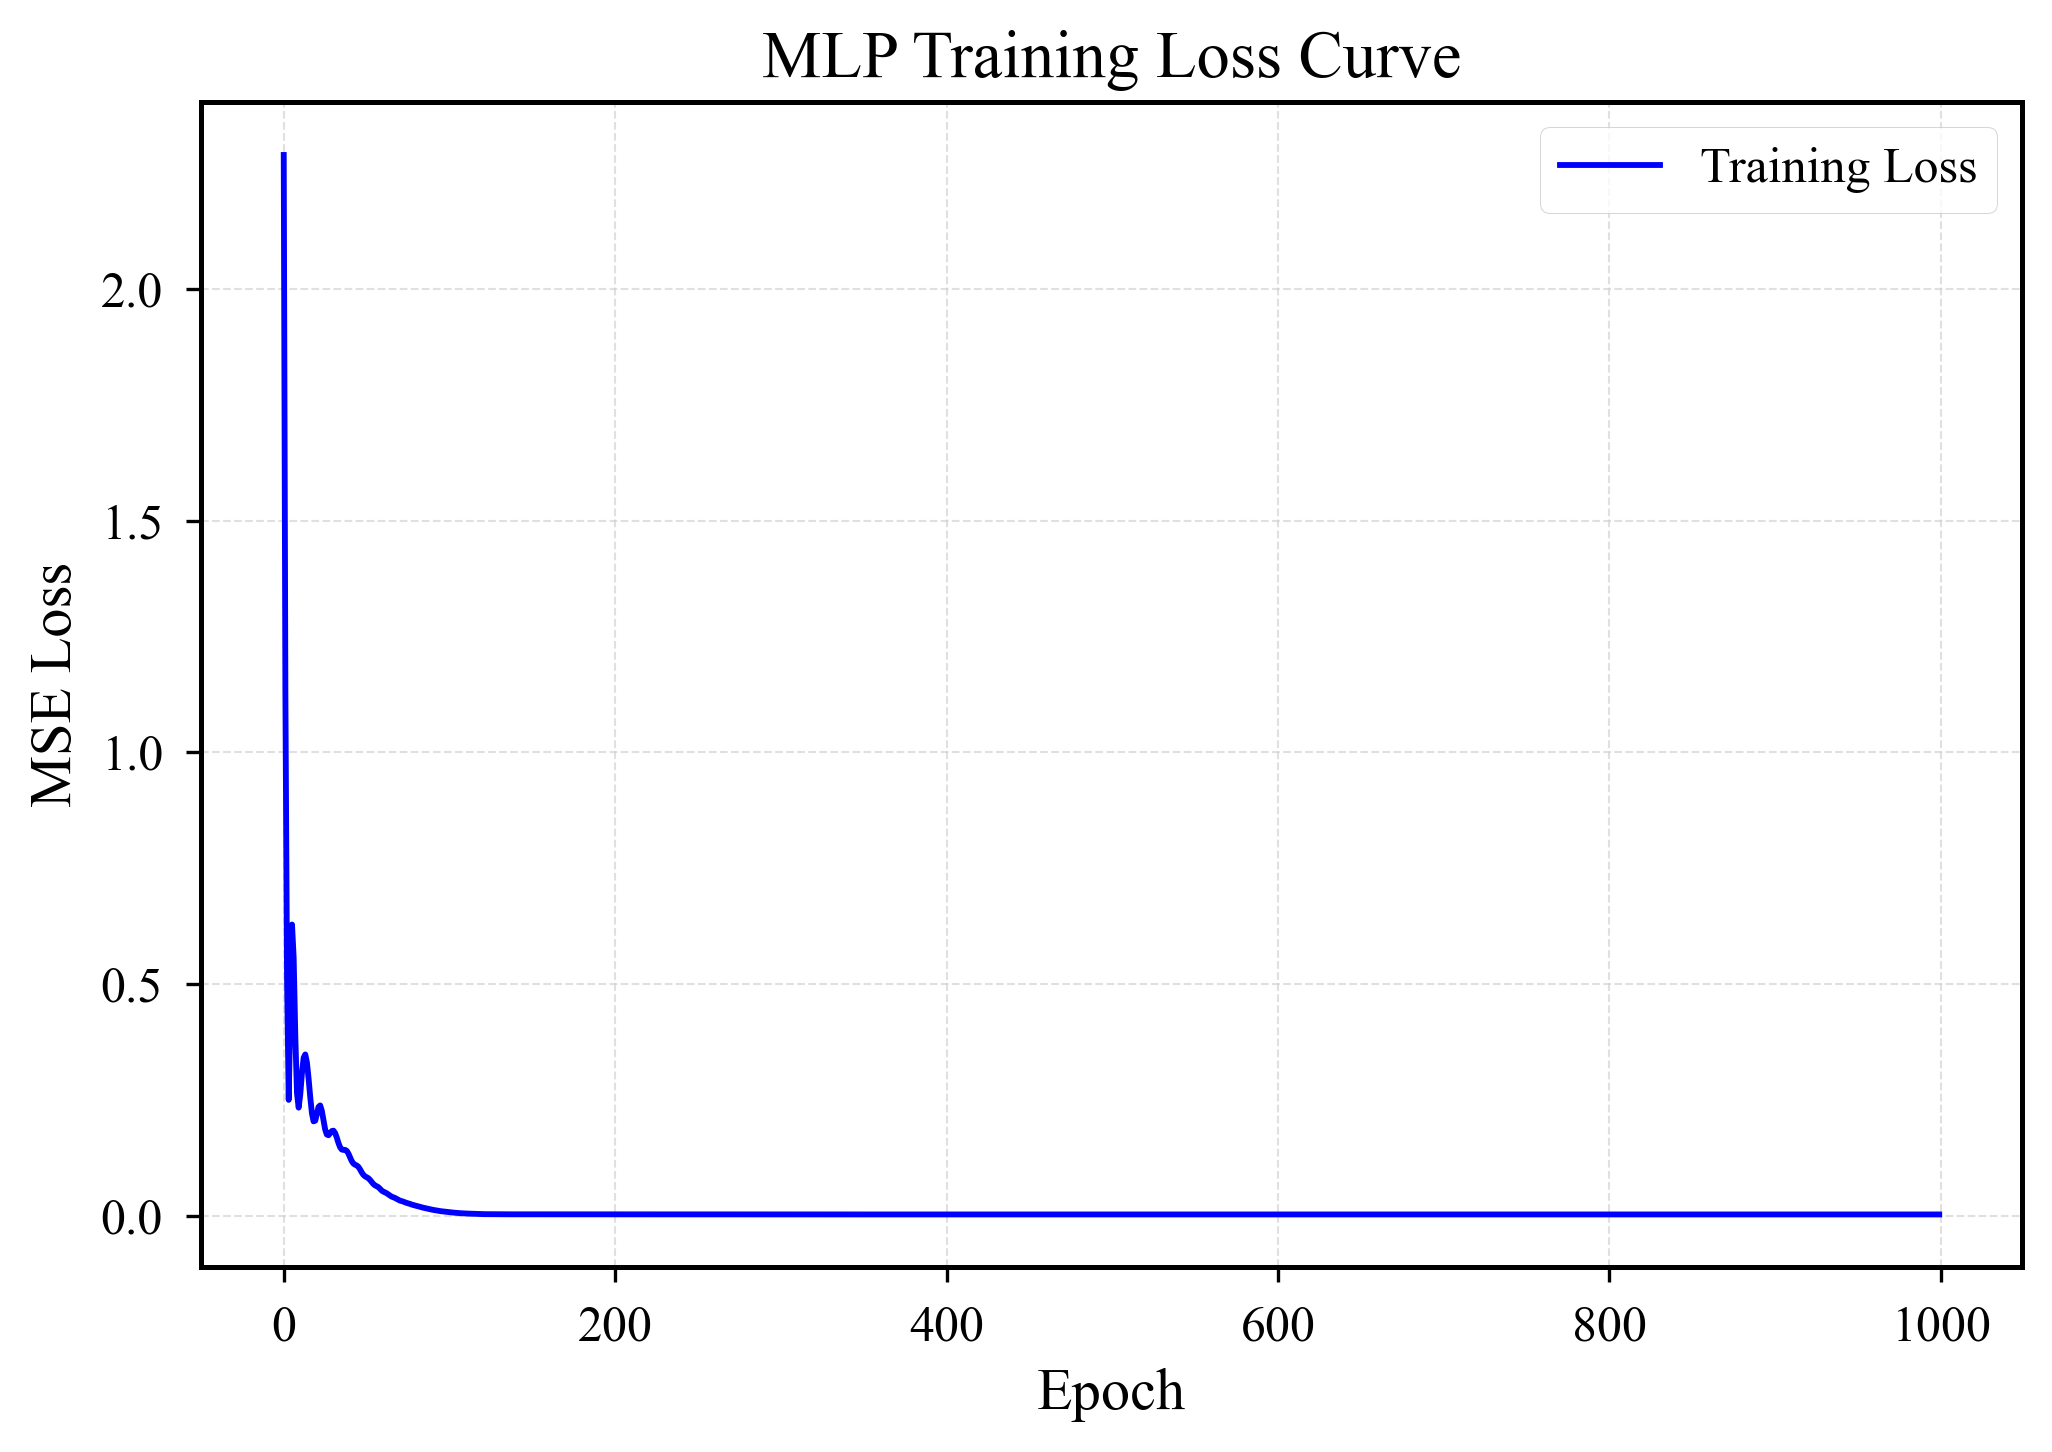

In [5]:
plt.plot(all_loss, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('MLP Training Loss Curve')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

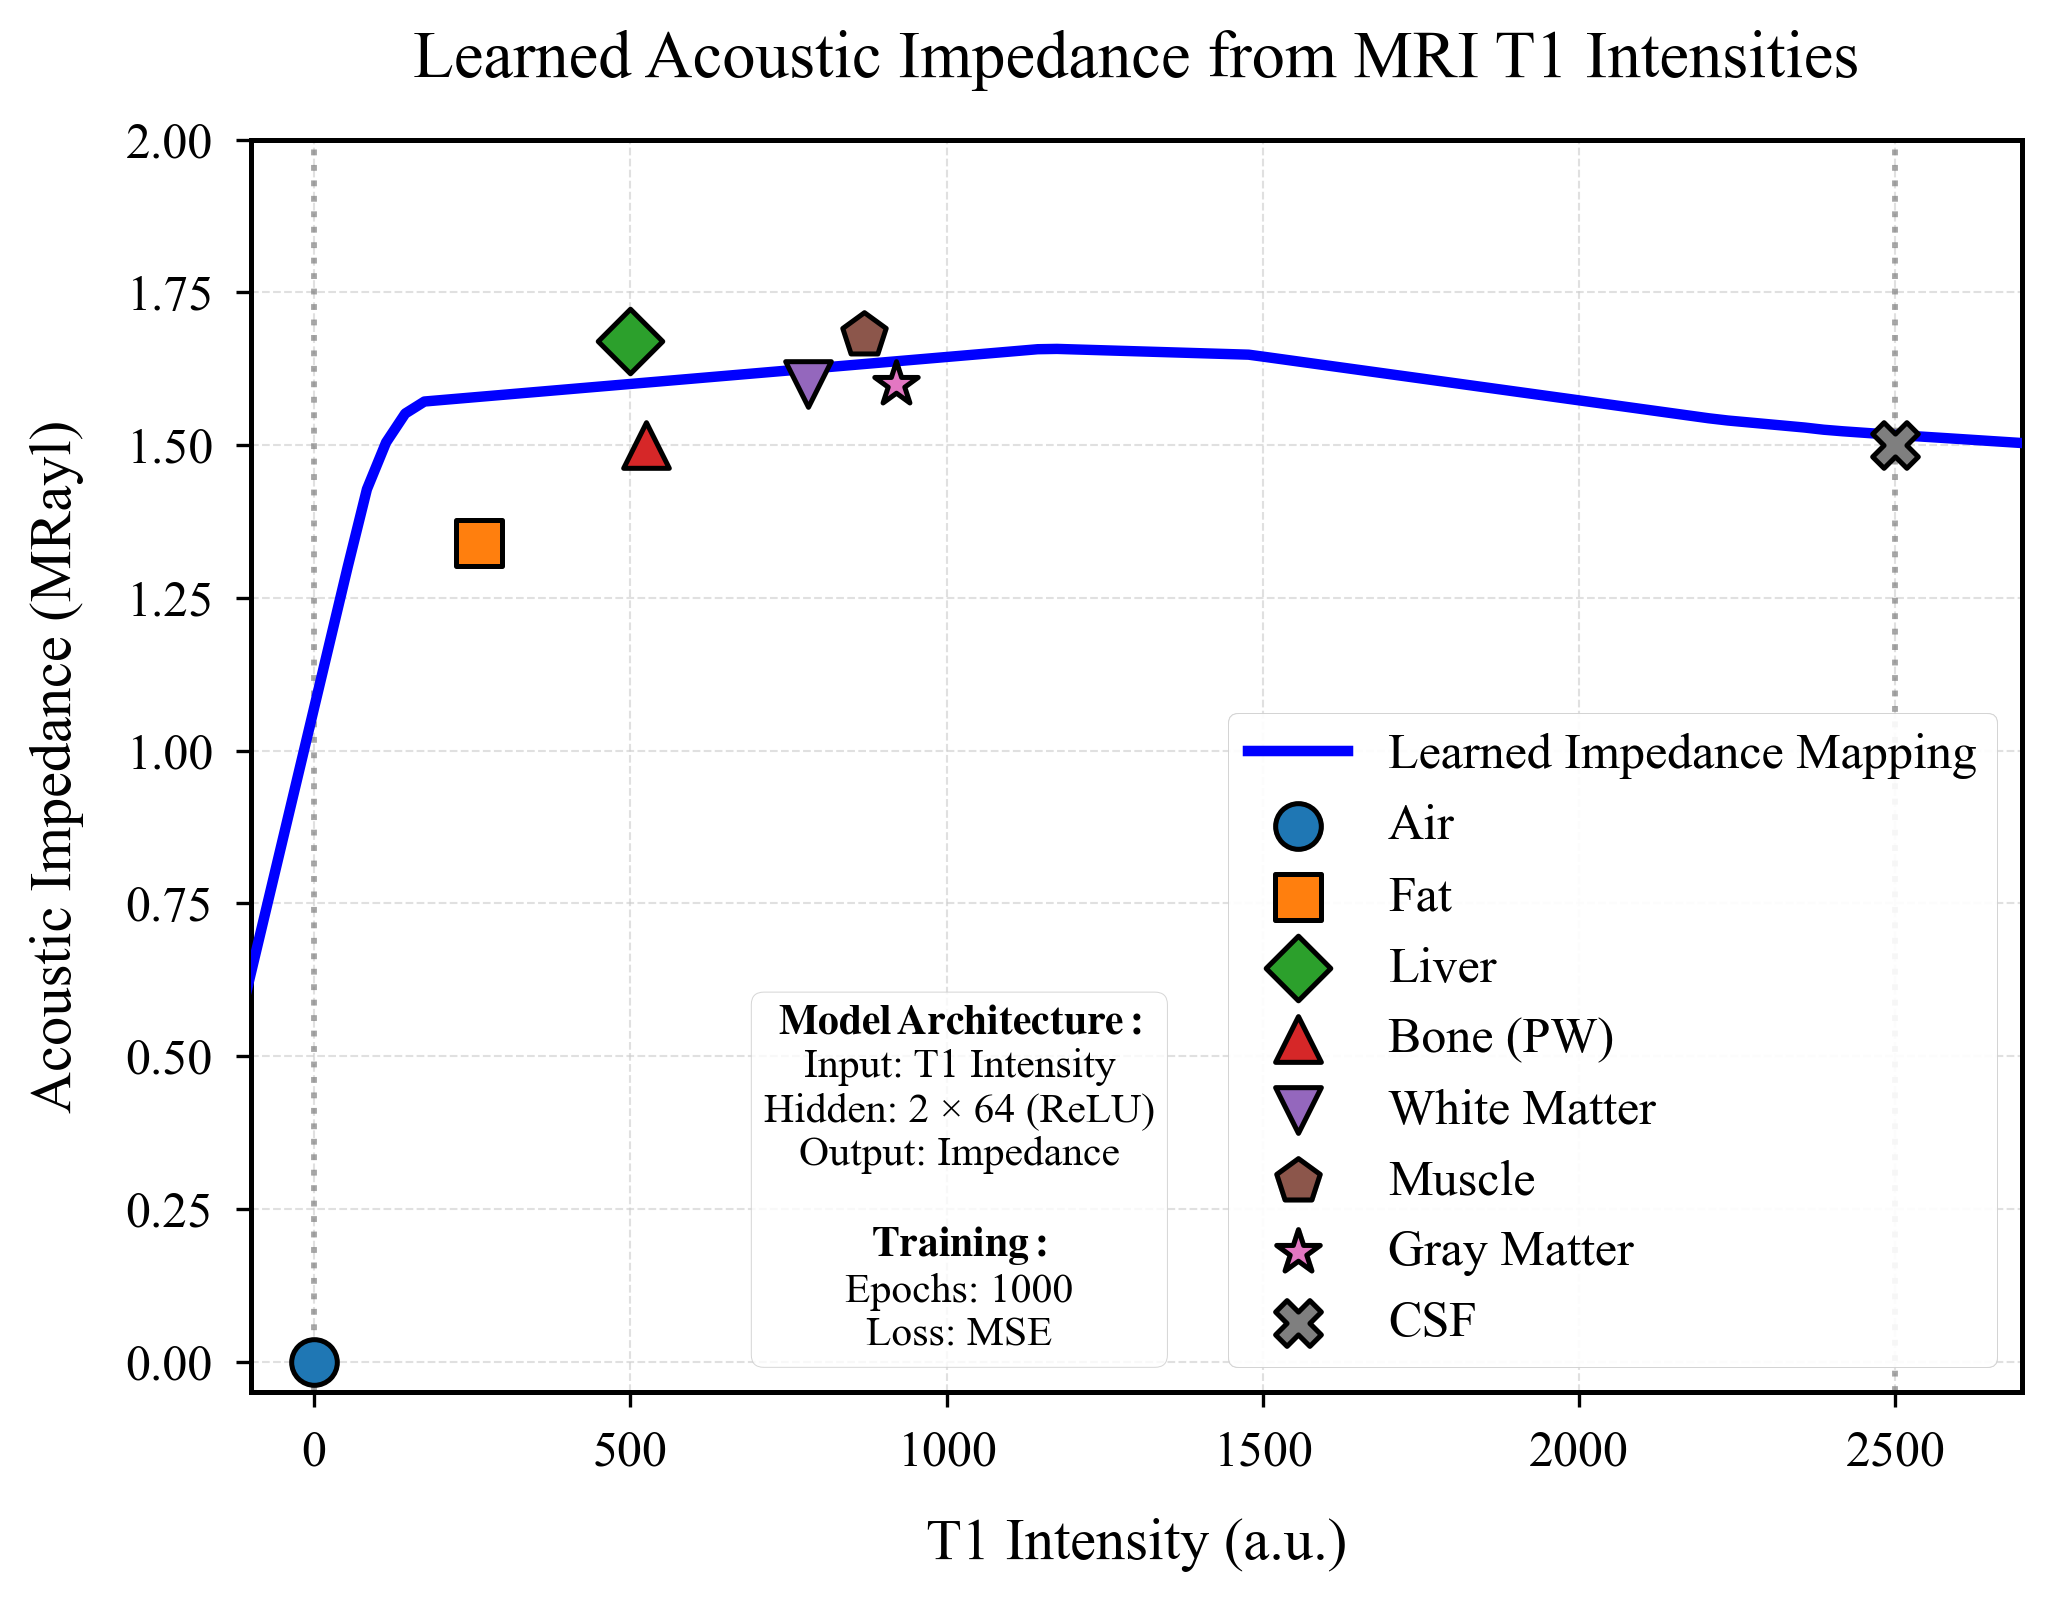

In [6]:
fig, ax = plt.subplots(figsize=(7, 5.5))

x_curve_original = min_int + (x_range) * (max_int - min_int)
ax.plot(x_curve_original, y_pred, 'b-', linewidth=2.5, label='Learned Impedance Mapping', zorder=10)

markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X']
colors = plt.cm.tab10.colors

for i, (_, row) in enumerate(tissue_data.iterrows()):
        ax.scatter(row['T1 Intensity'], row['Impedance (MRayl)'],
                           s=120, marker=markers[i % len(markers)], color=colors[i % len(colors)],
                           edgecolor='k', linewidth=1.2, label=row['Tissue'], zorder=20)

ax.axvline(x=min_int, color='gray', linestyle=':', alpha=0.7)
ax.axvline(x=max_int, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('T1 Intensity (a.u.)', fontsize=14, labelpad=10)
ax.set_ylabel('Acoustic Impedance (MRayl)', fontsize=14, labelpad=10)
ax.set_title('Learned Acoustic Impedance from MRI T1 Intensities', fontsize=16, pad=15)
ax.set_xlim(-100, 2700)
ax.set_ylim(-0.05, 2.0)
ax.set_xticks(np.arange(0, 2600, 500))
ax.set_yticks(np.arange(0.0, 2.1, 0.25))
ax.grid(True, linestyle='--', alpha=0.6)
main_legend = ax.legend(loc='lower right', framealpha=0.7, fancybox=True, shadow=False, ncol=1)
ax.add_artist(main_legend)

model_info = (
        r"$\bf{Model\,Architecture:}$" "\n"
        "Input: T1 Intensity\n"
        "Hidden: 2 × 64 (ReLU)\n"
        "Output: Impedance\n\n"
        r"$\bf{Training:}$" "\n"
        "Epochs: 1000\n"
        "Loss: MSE"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.8')
ax.text(0.4, 0.03, model_info, transform=ax.transAxes, fontsize=10, horizontalalignment="center", verticalalignment='bottom', bbox=props)

plt.tight_layout()
plt.show()
plt.close(fig)

And finally, let's save the model.

In [ ]:
model_path = data_path / 'mlp_impedance_estimator'
model_path.mkdir(parents=True, exist_ok=True)
torch.save(model, model_path / "impedance_estimator.pth")